# Multimodal-TERS Inference

Run inference with a pretrained **Multimodal Attention U-Net** on held-out samples and visualise:
- Input spectral image (mean across channels)
- Ground-truth segmentation mask (H, C, N, O)
- Predicted segmentation mask
- Per-channel Dice scores
- Frequency peaks used as input

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torchvision.transforms as transforms

# Make sure the project root is on the path
PROJECT_ROOT = os.path.abspath('')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.models.multimodal_unet import MultimodalAttentionUNet
from src.datasets.multimodal_ters import MultimodalTERSDataset
from src.transforms import NormalizeVectorized, MinimumToZeroVectorized

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Configuration

Set the checkpoint folder and data path below.

In [ ]:
# ── Checkpoint ────────────────────────────────────────────────────────────────
# Pick one of: none | early | late | attention | film | hybrid
FUSION_TYPE   = 'late'
CKPT_PATH     = f'model_checkpoints/{FUSION_TYPE}_fusion/best_model.pt'

# ── Data ──────────────────────────────────────────────────────────────────────
DATA_PATH     = '/scratch/phys/sin/sethih1/Multimodal_TERS/planar_hdf5_0.05/val.h5'
SAMPLE_IDX    = 0    # index of the sample to run inference on

# ── Model hyper-params (must match the checkpoint) ────────────────────────────
NUM_CHANNELS  = 100
MAX_FREQS     = 100
FREQ_ENCODING = 'binning'   # binning | normalize

# ── Visualisation ─────────────────────────────────────────────────────────────
THRESHOLD     = 0.5  # sigmoid threshold for binary prediction

ATOM_NAMES    = ['H', 'C', 'N', 'O']
ATOM_COLORS   = ['#4C9BE8', '#555555', '#3DBE7A', '#E85C5C']  # H=blue C=grey N=green O=red

print(f'Checkpoint : {CKPT_PATH}')
print(f'Data       : {DATA_PATH}')
print(f'Sample idx : {SAMPLE_IDX}')

Checkpoint : model_checkpoints/late_fusion/best_model.pt
Data       : /scratch/phys/sin/sethih1/Multimodal_TERS/planar_hdf5_0.05/val.h5


## Load model

In [5]:
model = MultimodalAttentionUNet(
    in_channels=NUM_CHANNELS,
    out_channels=4,
    filters=[64, 128, 256, 512],
    att_channels=64,
    kernel_size=[3, 3, 3, 3],
    max_freqs=MAX_FREQS,
    freq_embed_dim=128,
    freq_output_dim=512,
    fusion_type=FUSION_TYPE
).to(device)

state_dict = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Loaded checkpoint: {CKPT_PATH}')
print(f'Parameters: {total_params:,}')

Loaded checkpoint: model_checkpoints/late_fusion/best_model.pt
Parameters: 27,521,616


## Load dataset

In [6]:
transform = transforms.Compose([
    NormalizeVectorized(),
    MinimumToZeroVectorized()
])

dataset = MultimodalTERSDataset(
    hdf5_path=DATA_PATH,
    num_channels=NUM_CHANNELS,
    max_freqs=MAX_FREQS,
    t_image=transform,
    train_aug=False,
    freq_encoding=FREQ_ENCODING
)
print(f'Validation samples: {len(dataset)}')

Loaded 184 samples from /scratch/phys/sin/sethih1/Multimodal_TERS/planar_hdf5_0.05/val.h5
Validation samples: 184


## Helper functions

In [7]:
def run_inference(sample):
    """Run a single sample through the model and return prediction."""
    image      = sample['image'].unsqueeze(0).to(device)           # (1, C, H, W)
    frequencies = sample['frequencies'].unsqueeze(0).to(device)    # (1, max_freqs)
    freq_mask  = sample.get('freq_mask')
    if freq_mask is None:
        freq_mask = torch.ones_like(frequencies)
    else:
        freq_mask = freq_mask.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image, frequencies, freq_mask)   # (1, 4, H, W)
        pred   = (torch.sigmoid(output) > THRESHOLD).float()

    return pred.squeeze(0).cpu().numpy()  # (4, H, W)


def dice_per_channel(pred, target):
    """Compute Dice score for each of the 4 atom channels."""
    scores = []
    for c in range(4):
        p, t = pred[c], target[c]
        inter = (p * t).sum()
        denom = p.sum() + t.sum()
        scores.append((2 * inter + 1e-6) / (denom + 1e-6))
    return scores


def mask_to_rgb(mask_4ch):
    """Overlay 4-channel binary mask into a single RGB image for display."""
    H, W = mask_4ch.shape[1], mask_4ch.shape[2]
    rgb = np.ones((H, W, 3))
    for c, hex_color in enumerate(ATOM_COLORS):
        r = int(hex_color[1:3], 16) / 255
        g = int(hex_color[3:5], 16) / 255
        b = int(hex_color[5:7], 16) / 255
        active = mask_4ch[c] > 0
        rgb[active] = [r, g, b]
    return rgb


def decode_frequencies(freq_tensor, freq_encoding, max_freq=4000):
    """Recover peak positions (cm⁻¹) from the encoded frequency vector."""
    freq = freq_tensor.numpy()
    if freq_encoding == 'binning':
        num_bins = len(freq)
        bin_width = max_freq / num_bins
        peaks = np.where(freq > 0)[0] * bin_width + bin_width / 2
    else:  # normalize
        peaks = freq[freq > 0] * max_freq
    return peaks



Helper functions ready.


## Run inference and visualise

Single sample: **mean spectral image | ground truth | prediction | per-channel Dice | frequency peaks**

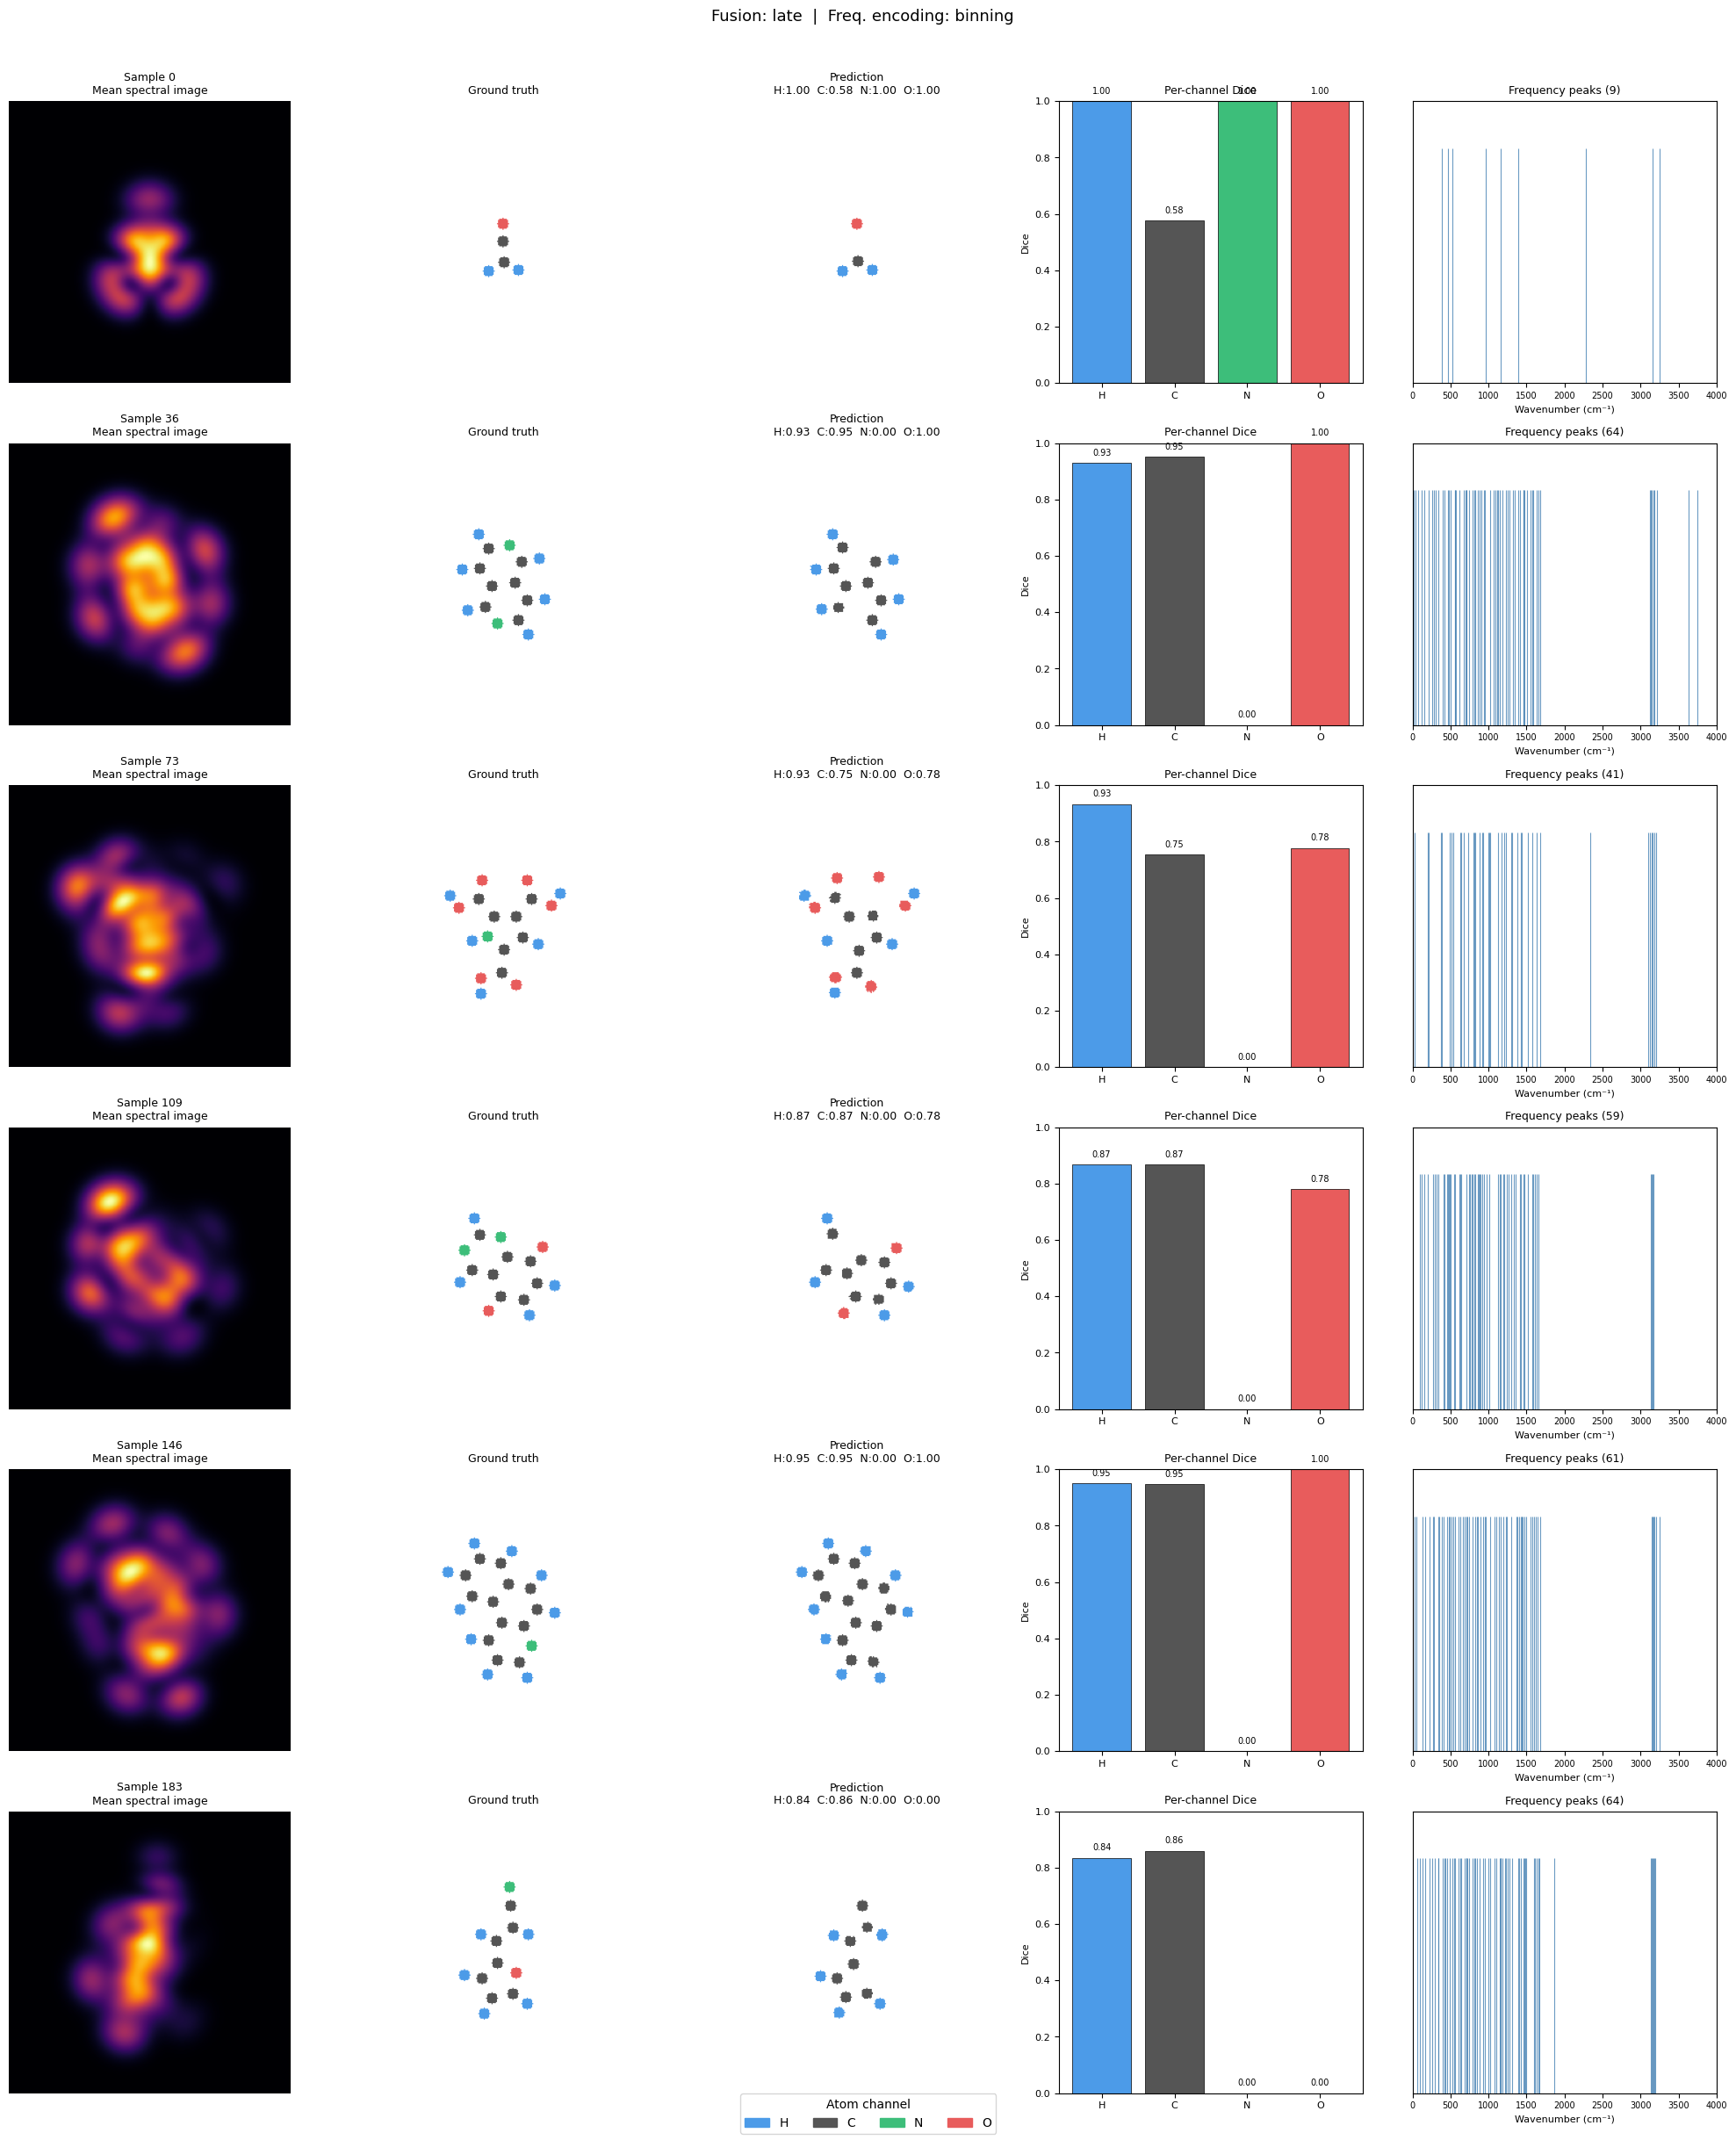

Figure saved to inference_late.png


In [ ]:
import matplotlib.patches as mpatches

sample  = dataset[SAMPLE_IDX]
image   = sample['image'].numpy()    # (C, H, W)
target  = sample['target'].numpy()   # (4, H, W)
freqs   = sample['frequencies']

pred    = run_inference(sample)      # (4, H, W)
dices   = dice_per_channel(pred, target)

mean_img = image.mean(axis=0)
gt_rgb   = mask_to_rgb(target)
pred_rgb = mask_to_rgb(pred)
peaks    = decode_frequencies(freqs, FREQ_ENCODING)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

# --- Col 0: mean spectral image ---
axes[0].imshow(mean_img, cmap='inferno')
axes[0].set_title(f'Sample {SAMPLE_IDX}\nMean spectral image', fontsize=10)
axes[0].axis('off')

# --- Col 1: ground truth ---
axes[1].imshow(gt_rgb)
axes[1].set_title('Ground truth', fontsize=10)
axes[1].axis('off')

# --- Col 2: prediction ---
axes[2].imshow(pred_rgb)
dice_str = '  '.join([f'{ATOM_NAMES[i]}:{dices[i]:.2f}' for i in range(4)])
axes[2].set_title(f'Prediction\n{dice_str}', fontsize=10)
axes[2].axis('off')

# --- Col 3: per-channel Dice bar ---
bars = axes[3].bar(ATOM_NAMES, dices, color=ATOM_COLORS, edgecolor='black', linewidth=0.6)
axes[3].set_ylim(0, 1)
axes[3].set_ylabel('Dice')
axes[3].set_title('Per-channel Dice', fontsize=10)
for bar, val in zip(bars, dices):
    axes[3].text(bar.get_x() + bar.get_width() / 2, val + 0.02, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=8)

# --- Col 4: frequency peaks ---
axes[4].vlines(peaks, 0, 1, color='steelblue', linewidth=0.8, alpha=0.8)
axes[4].set_xlim(0, 4000)
axes[4].set_ylim(0, 1.2)
axes[4].set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
axes[4].set_title(f'Frequency peaks ({len(peaks)})', fontsize=10)
axes[4].set_yticks([])

legend_patches = [mpatches.Patch(color=ATOM_COLORS[i], label=ATOM_NAMES[i]) for i in range(4)]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10,
           frameon=True, title='Atom channel', bbox_to_anchor=(0.5, -0.12))

plt.suptitle(f'Fusion: {FUSION_TYPE}  |  Freq. encoding: {FREQ_ENCODING}', fontsize=12)
plt.tight_layout()
plt.savefig(f'inference_{FUSION_TYPE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Avg Dice: {sum(dices)/len(dices):.4f}')

## Compare all fusion strategies

Run the same single sample through every available checkpoint and plot a grouped Dice bar chart.

In [ ]:
ALL_FUSION_TYPES = ['none', 'early', 'late', 'attention', 'film', 'hybrid']
results = {}   # fusion_type -> dice scores (list of 4)

sample  = dataset[SAMPLE_IDX]
target  = sample['target'].numpy()

for ft in ALL_FUSION_TYPES:
    ckpt = f'model_checkpoints/{ft}_fusion/best_model.pt'
    if not os.path.exists(ckpt):
        print(f'[skip] {ckpt} not found')
        continue

    m = MultimodalAttentionUNet(
        in_channels=NUM_CHANNELS, out_channels=4,
        filters=[64, 128, 256, 512], att_channels=64,
        kernel_size=[3, 3, 3, 3], max_freqs=MAX_FREQS,
        freq_embed_dim=128, freq_output_dim=512, fusion_type=ft
    ).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()

    image       = sample['image'].unsqueeze(0).to(device)
    frequencies = sample['frequencies'].unsqueeze(0).to(device)
    freq_mask   = sample.get('freq_mask')
    if freq_mask is None:
        freq_mask = torch.ones_like(frequencies)
    else:
        freq_mask = freq_mask.unsqueeze(0).to(device)

    with torch.no_grad():
        out  = m(image, frequencies, freq_mask)
        pred = (torch.sigmoid(out) > THRESHOLD).float().squeeze(0).cpu().numpy()

    results[ft] = dice_per_channel(pred, target)
    print(f'{ft:10s}  {"  ".join([f"{ATOM_NAMES[i]}:{results[ft][i]:.3f}" for i in range(4)])}  '
          f'avg:{sum(results[ft])/4:.3f}')

# --- Grouped bar chart ---
if results:
    ft_labels = list(results.keys())
    data = np.array([results[ft] for ft in ft_labels])   # (n_fusions, 4)

    x = np.arange(len(ft_labels))
    width = 0.18
    fig, ax = plt.subplots(figsize=(11, 4))
    for i in range(4):
        ax.bar(x + i * width, data[:, i], width, label=ATOM_NAMES[i],
               color=ATOM_COLORS[i], edgecolor='black', linewidth=0.5)
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(ft_labels)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Dice score')
    ax.set_title(f'Fusion strategy comparison — sample {SAMPLE_IDX}')
    ax.legend(title='Atom', fontsize=9)
    plt.tight_layout()
    plt.savefig('fusion_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fusion_comparison.png')

[skip] model_checkpoints/ablation-none_fusion-none_freq-binning_seed-42/best_model.pt not found
[skip] model_checkpoints/ablation-early_fusion-early_freq-binning_seed-42/best_model.pt not found
[skip] model_checkpoints/ablation-late_fusion-late_freq-binning_seed-42/best_model.pt not found
[skip] model_checkpoints/ablation-attention_fusion-attention_freq-binning_seed-42/best_model.pt not found
[skip] model_checkpoints/ablation-film_fusion-film_freq-binning_seed-42/best_model.pt not found
[skip] model_checkpoints/ablation-hybrid_fusion-hybrid_freq-binning_seed-42/best_model.pt not found


In [11]:
dataset.close()